## Інструкція з використання:

1. **Налаштування гармоніки:** За допомогою повзунків "*Amplitude*", "*Frequency*" та "*Phase*" можна змінювати амплітуду, частоту і фазовий зсув основного сигналу.

2. **Налаштування шуму:** Повзунки "*Noise Mean*" і "*Noise Covariance*" дозволяють змінювати середнє значення та інтенсивність шуму. Шумова основа залишається сталою, тому при зміні параметрів гармоніки форма шуму не перебудовується випадковим чином.

3. **Параметри фільтра:** За допомогою "*Cutoff Frequency*" можна регулювати силу фільтрації сигналу: менше значення забезпечує сильніше згладжування.

4. **Відображення шуму:** Чекбокс "*Show Noise*" дозволяє вмикати або вимикати показ зашумленого сигналу на графіку.

5. **Відновлення параметрів:** Кнопка "*Reset*" повертає всі налаштування до початкового стану.

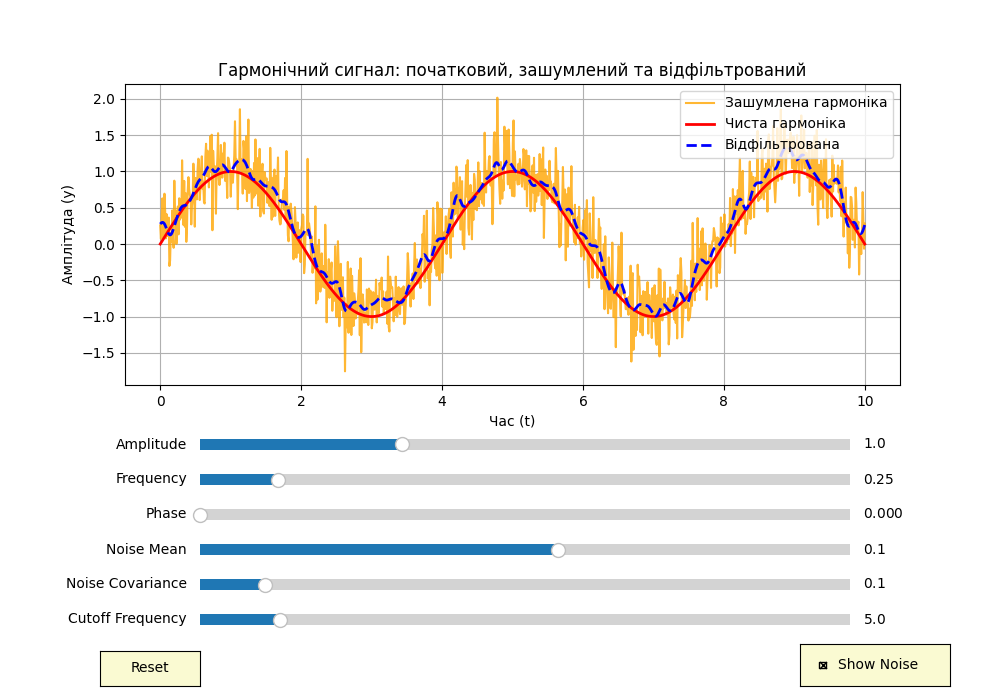

In [11]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import butter, filtfilt

# 1. Початкові параметри

t = np.linspace(0, 10, 1000)
fs = 100.0 

A_init = 1
f_init = 0.25
phi_init = 0.0
n_mean_init = 0.1
n_cov_init = 0.1
cutoff_init = 5.0

np.random.seed(42)
base_noise = np.random.normal(0, 1, len(t))

# 2. Функції
def harmonic_with_noise(amplitude, frequency, phase,
                        noise_mean, noise_covariance,
                        show_noise=True):

    clean_signal = amplitude * np.sin(2 * np.pi * frequency * t + phase)

    std_dev = np.sqrt(max(noise_covariance, 0.0001))
    noise = base_noise * std_dev + noise_mean

    if show_noise:
        noisy_signal = clean_signal + noise
    else:
        noisy_signal = clean_signal

    return clean_signal, noisy_signal


def filter_signal(data, cutoff):
    
    nyq = 0.5 * fs
    normal_cutoff = np.clip(cutoff / nyq, 0.01, 0.99)

    b, a = butter(3, normal_cutoff, btype='low')
    filtered_signal = filtfilt(b, a, data)

    return filtered_signal


# 3. Початкові дані

y_clean, y_noisy = harmonic_with_noise(
    A_init, f_init, phi_init,
    n_mean_init, n_cov_init,
    True
)

y_filtered = filter_signal(y_noisy, cutoff_init)

# 4. Створення графіка
fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(bottom=0.45)

line_noisy, = ax.plot(
    t, y_noisy,
    color='orange',
    alpha=0.8,
    label='Зашумлена гармоніка'
)

line_clean, = ax.plot(
    t, y_clean,
    color='red',
    linewidth=2,
    label='Чиста гармоніка'
)

line_filtered, = ax.plot(
    t, y_filtered,
    color='blue',
    linestyle='--',
    linewidth=2,
    label='Відфільтрована'
)

ax.set_title("Гармонічний сигнал: початковий, зашумлений та відфільтрований")
ax.set_xlabel("Час (t)")
ax.set_ylabel("Амплітуда (y)")
ax.legend(loc='upper right')
ax.grid(True)

# 5. Слайдери
axcolor = 'lightgoldenrodyellow'

ax_A = plt.axes([0.2, 0.35, 0.65, 0.03], facecolor=axcolor)
ax_f = plt.axes([0.2, 0.30, 0.65, 0.03], facecolor=axcolor)
ax_phi = plt.axes([0.2, 0.25, 0.65, 0.03], facecolor=axcolor)
ax_n_mean = plt.axes([0.2, 0.20, 0.65, 0.03], facecolor=axcolor)
ax_n_cov = plt.axes([0.2, 0.15, 0.65, 0.03], facecolor=axcolor)
ax_cutoff = plt.axes([0.2, 0.10, 0.65, 0.03], facecolor=axcolor)

s_A = Slider(ax_A, 'Amplitude', 0.1, 3.0, valinit=A_init)
s_f = Slider(ax_f, 'Frequency', 0.01, 2.0, valinit=f_init)
s_phi = Slider(ax_phi, 'Phase', 0.0, 2*np.pi, valinit=phi_init)
s_n_mean = Slider(ax_n_mean, 'Noise Mean', -1.0, 1.0, valinit=n_mean_init)
s_n_cov = Slider(ax_n_cov, 'Noise Covariance', 0.0, 1.0, valinit=n_cov_init)
s_cutoff = Slider(ax_cutoff, 'Cutoff Frequency', 0.1, 40.0, valinit=cutoff_init)

# 6. Чекбокс
ax_check = plt.axes([0.8, 0.02, 0.15, 0.06], facecolor=axcolor)
check = CheckButtons(ax_check, ['Show Noise'], [True])

# 7. Кнопка Reset
ax_reset = plt.axes([0.1, 0.02, 0.1, 0.05])
btn_reset = Button(ax_reset, 'Reset', color=axcolor, hovercolor='0.975')

# 8. Оновлення графіка
def update(val):
    show_noise = check.get_status()[0]

    new_clean, new_noisy = harmonic_with_noise(
        s_A.val,
        s_f.val,
        s_phi.val,
        s_n_mean.val,
        s_n_cov.val,
        show_noise
    )

    new_filtered = filter_signal(new_noisy, s_cutoff.val)

    line_clean.set_ydata(new_clean)
    line_noisy.set_ydata(new_noisy)
    line_filtered.set_ydata(new_filtered)

    fig.canvas.draw_idle()


def toggle_noise(label):
    update(None)


def reset(event):
    s_A.reset()
    s_f.reset()
    s_phi.reset()
    s_n_mean.reset()
    s_n_cov.reset()
    s_cutoff.reset()

# 9. Прив’язка подій
s_A.on_changed(update)
s_f.on_changed(update)
s_phi.on_changed(update)
s_n_mean.on_changed(update)
s_n_cov.on_changed(update)
s_cutoff.on_changed(update)

check.on_clicked(toggle_noise)
btn_reset.on_clicked(reset)

plt.show()